# Homework 3 (The Majestic Mosaic)

> Before you get terrified: It looks like a lot but it boils down to 15 lines of code for all tasks. I ask you to write it in a nice way, so it will be a little more + comments.

## Lin. Alg. for Data Science, Fall 23
## Due date: hopefully a reasonable one, see discord

Collaboration rules:
For this task, **feel free to discuss any details on discord**, share outputs etc. I'm just asking you to refrain from posting code (working or otherwise). But you can describe the code in words. I just don't want people to blindly copy paste someone elses solution.

Instructions:
Solve the tasks (by writing python code).

Prefix the name of the notebook with your name (e.g. Marian_the_Mosaic_Maker_HW3.ipynb)

Run all the cells in the notebook, so that all results are visible.

Important: on colab create a shared link using the option "for anyone with the link" and switch permission from Viewer to Editor; verify it says "Anyone on the internet with the link can edit".

Submit the above link on canvas before the deadline. Do not modify the notebook after that.

The day after the final deadline, you will be required to answer some brief questions about your solution via a google form I will send you. This is part of the homework assignment!

# The mosaic

The idea is to take an image -- and replace each pixel with a small image. The result will resemble a mosaic made of small colorful tiles. The image bekiw shows a close-up of such a mosaic.

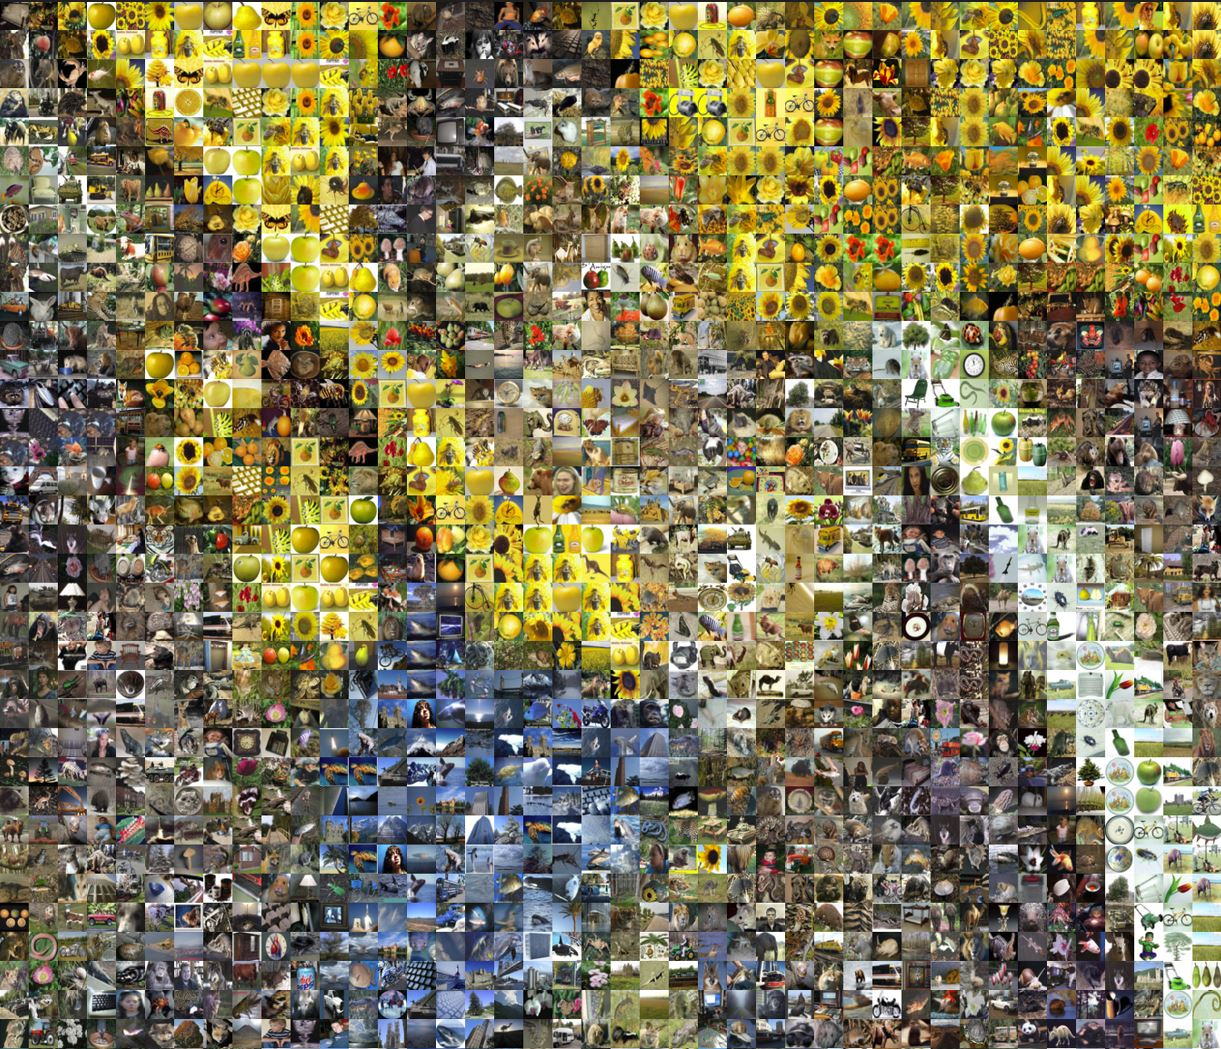

# Proposed algorithm
Computationally this is a hard task!
We will use an image with $P$ = ~200'000 pixels in an image. But it could easily be millions or even billions of pixels.

And for each pixel we will have to find a matching image. We will use cifar100 for the tiles, so that $T$ = 50'000 images. But it could easily be millions of images!

So a naive algorithm would have complexity $\Omega(PT)$ -- it's already terrible, but we haven't even considered that the tiles can be fairly large.

> You can try to brute-force it tell us how long it took.

**What to do, what to do!?**

First, by **input image** I mean the single large-ish image we want to turn into a mosaic. By a tile I mean each of the many small images which will be the tiles of the resulting mosaic.

In our example the input is 512x512 and the tiles are 32x32. Both are RGB images.

Now, we will do a couple of tricks:
- To find the matching tile, we will consider its mean color and compare it with the pixel which it's meant to replace. We just reduced the dimensionality of our data from $32*32*3$ to $3$. And it makes sense here!

> It's useful to think of these RGB vectors as *fingerprints* of the images. They contain only the crucial data (in this case mean color), but make the search process much easier.

- Since now our data is now 3-dimensional, we can just use kd-trees to look for nearest neighbours!

> You should remember from our notebook that kd-trees are super efficient for low dimensions, but their performance totally degrades around d=100.

- So we will build a kd-tree on top of the mean-colors of tiles and query for each pixel in the input image.

> Note that a single query returns an index of the nearest mean-color -- but that's also the index of the tile we want!

- So now we have an index of a tile for each pixel in the input image.

- The last step is to convery these indices to the final image -- that's just (no so) basic numpy.

# Some things to watch out for:

> This could be some preemptive tips from a more experienced teammate, who solved similar problems

- Do *not* normalize the tiles, by dividing by 255. Keep the values as integers between 0 and 255. Note after loading cifar100 numpy represent each RGB intensity as a np.uint8 type. It only needs 1 byte of memory. The default floating point value (np.float64) uses 8 bytes (64 bits). Normally it's not an issue, but we will generate very large images -- so if we use floats memory will likely blow up.

- The means can be stored as floats -- they don't take up too much space. So they should be *floats* between 0 and 255.

- You can imshow a single color (RGB vector) by reshaping it into a vector with shape (1,1,3).

- Remember you can create a larger figure, e.g. plt.figure(figsize=(20, 20))

- The hardest part is re-arranging the tiles in the correct order. It's not a simple reshape. The easy way of doing it, is to create a large empty np.array representing the ouput image -- and paste each tile in te appropriate place in it. Rembmer about the fancy indexing like: output[32:64, 64:96] = some_tile.

- A more advanced way would be to do an intricate usage of np.transpose and then np.reshape.

- Overall, the main algorthm can be done in 5 lines of code with no explicit loops.

- You can save the resulting nparray as an '.png' or '.jpg' image like this: Image.fromarray(result).save('out.png')

> The png version will be compressed losslessly and will look much better than jpg -- but the file may be huge! You can then download it and zoom in on your compute as I did in class. The jpg will be smaller but may look bad.

> If you did everything perfectly, the computations should take maybe 5 seconds -- escept downloading data and saving the huge image. So by default I wouldn't save it -- only if I really want to download it. BTW. Colab's local files are accessible in the tab to the left (at least normally).



# Coding quality (link is part of assignemt!)

This part is described here (mostly because I may update it, but I want you to get started asap).

https://colab.research.google.com/drive/129_RlLvBJk9FS87Fs5XzWo8xJUR9I4Ak?usp=sharing

If your programming experience is limited, don't stress out too much. Ask questions on discord if needed, and try to do your best. Once we're done, we'll share some good solutions, so that you can see what should have been done. In terms of scoring, I will try to look more at effort than results.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KDTree
from PIL import Image
import urllib.request
from keras.datasets import cifar100 as tiles_dataset

!pip install pycodestyle pycodestyle_magic
!pip install flake8
%load_ext pycodestyle_magic

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 6.8 MB/s eta 0:00:00


# Data loading

In [ ]:
def get_image(img_URL, w):
  '''Just downloads an image, resizes to size w x w and
    returns it as an np.array.
    Note that no normalization is performed.
  '''
  file_name = 'input_image_name_on_disk'
  urllib.request.urlretrieve(img_URL, file_name)
  im = Image.open(file_name)
  im = im.resize((w, w))
  return np.asarray(im)[..., :3] # removes a potential alpha channel

In [ ]:
img_UF_URL = "http://people.clas.ufl.edu/hwagner/files/UF.png"
img_ravenna_URL = "http://people.clas.ufl.edu/hwagner/files/ravenna.jpg"

# Feel free to use another url for fun; it must point directly at an image file
mos = get_image(img_UF_URL, w = 512)

In [ ]:
tiles = tiles_dataset.load_data()[0][0]

169001437/169001437 [==============================] - 4s 0us/step


# Task 1: the proof-of-concept [weight ~0.2]
First, compute the mean colors of all the tiles and construct a kd-tree.

Now generate 10 random colors and query the kd-tree for the nearest neighbours. For each of the 10 colors, imshow (in a horizontal row): the original color, the nearest mean color and the tile corresponding to the mean color.

> The results should make sense. Keep in mind that we're talking about the mean color. So something red on a which background will be pink on average!

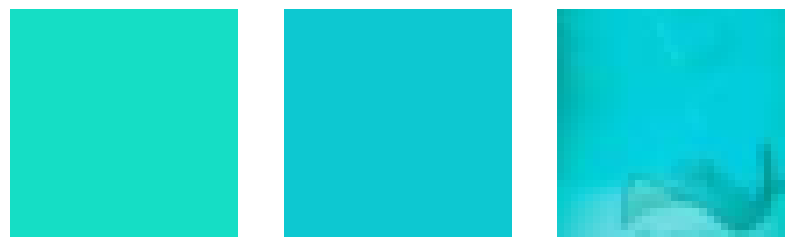

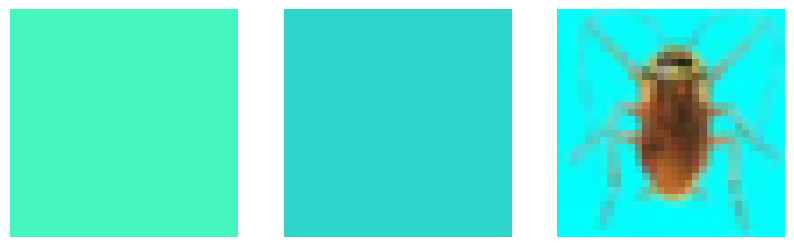

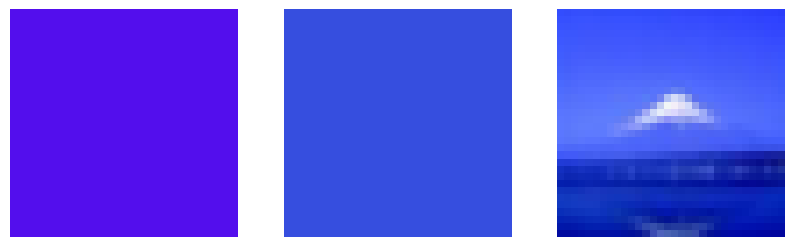

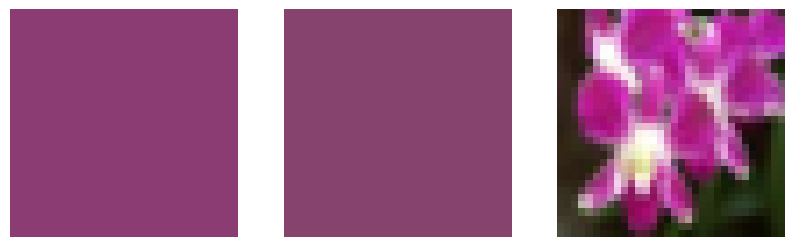

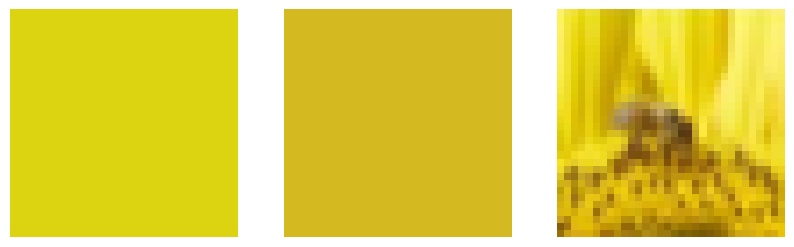

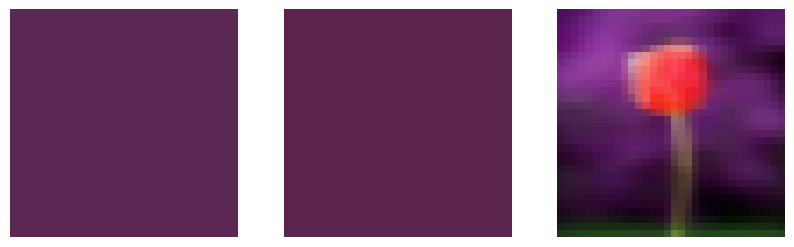

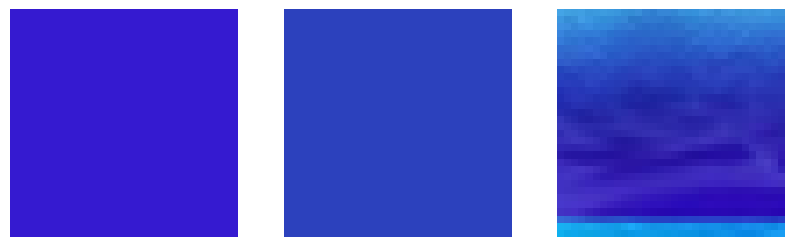

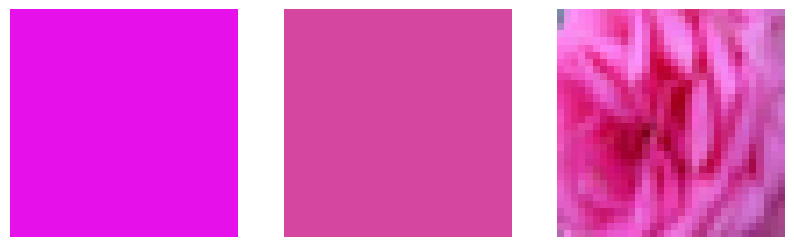

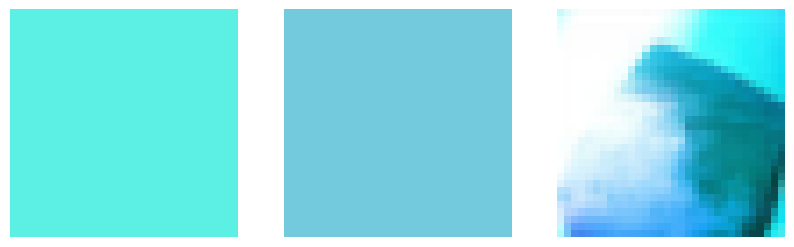

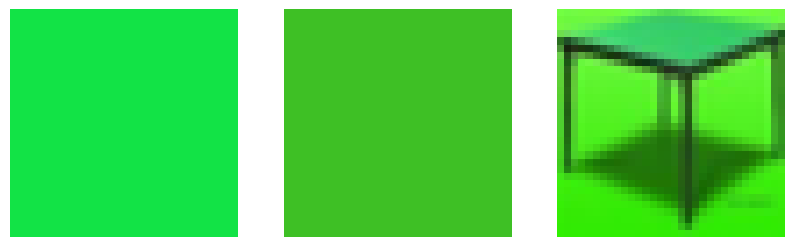

In [ ]:
# your code
#%%pycodestyle

# Credit to Professor Wagner for plotting images in a row
def plot_images_in_a_row(ims):
    'Takes a list/array of images and plots them spaced horizontally.'

    # assert ims: list or numpyarray, elements in ims list or nparray
    # assert 3 dimensional images with 3 channels
    assert isinstance(ims, (list, np.ndarray))
    assert all(isinstance(im, np.ndarray) for im in ims)
    assert all(im.ndim == 3 for im in ims)
    assert all(im.shape[2] == 3 for im in ims)
    _, axs = plt.subplots(1, len(ims), figsize=(10, 5))
    for im, ax in zip(ims, axs.ravel()):
        if im.shape == (3,):  # If the image data is a single color
            im = im.reshape(1, 1, 3)  # Reshape it into a 3D array
        elif im.shape == (1, 32, 32, 3):  # If the image data is a tile
            im = np.squeeze(im)
        ax.imshow(im)
        ax.axis('off')


# compute the mean colors of all tiles
tile_mean = [np.mean(tile, axis=(0, 1)) for tile in tiles]

# construct kd-tree
kd_tree = KDTree(tile_mean)

# generate 10 random colors and query kd-tree for nearest neighbors
rand_colors = np.random.randint(0, 256, size=(10, 3))
distances, indice = kd_tree.query(rand_colors)

# write assert tests random color and tile means have appropriate shape
assert rand_colors.shape == (10, 3)
assert len(tile_mean) == len(tiles)

# plot 10 images and corresponding colors
for i in range(10):
    original_color = rand_colors[i].reshape(1, 1, 3)
    nearest_mean_color = tile_mean[indice[i][0]].reshape(1,
                                                         1, 3).astype(np.uint8)
    tile_corresponding = tiles[indice[i][0]]

    # test correct shape
    assert original_color.shape == (1, 1, 3)
    assert nearest_mean_color.shape == (1, 1, 3)
    assert tile_corresponding.shape == (32, 32, 3)

    plot_images_in_a_row([original_color, nearest_mean_color,
                          tile_corresponding])


# check query result length
def test_kd_tree_query():
    rand_colors = np.random.randint(0, 256, size=(10, 3))
    distances, indices = kd_tree.query(rand_colors)
    assert len(distances) == len(indices) == 10


test_kd_tree_query()


def test_synthetic_case():
    # synthetic color array
    synthetic_colors = np.array([[255, 0, 0], [0, 255, 0], [0, 0, 255]])

    # Query the kd-tree for nearest neighbors
    distances, indices = kd_tree.query(synthetic_colors, k=1)

    # Assert that the distances and indices have the correct shape
    assert distances.shape == (3, 1)
    assert indices.shape == (3, 1)


test_synthetic_case()

# Task 2: the full-fledged implementation [weight ~0.7]

If everything looks good in task 1, we are ready for the full algorithm. Good luck!

> Make sure to follow the code-quality guidelines!

In [ ]:
# your code
#%%pycodestyle

# reshape into 2D array
mos_reshape = mos.reshape(-1, 3)

# assert mos_reshape is numpy array
assert isinstance(mos_reshape, np.ndarray)

# query KD Tree based on reshape
distances_res, indice_res = kd_tree.query(mos_reshape)

# create empty numpy array of n image rows and columns
mosaic = np.empty((mos.shape[0] * 32, mos.shape[1] * 32, 3), dtype=np.uint8)

# mos_reshape has the correct shape
assert mos_reshape.shape == (mos.shape[0] * mos.shape[1], 3)

# mosaic has the correct shape
assert mosaic.shape == (mos.shape[0] * 32, mos.shape[1] * 32, 3)

# all indices are valid
assert np.all((indice_res >= 0) & (indice_res < len(tiles)))

# loop over each pixel, list coordinates for pixels, and count iterations
for index, (i, j) in enumerate(np.ndindex(mos.shape[:2])):

    # select corresponding tile to image pixel based on indice nearest neighbor
    tile = tiles[indice_res[index][0]]

    # assign tile to position in mosaic
    mosaic[i * 32: (i + 1) * 32, j * 32: (j + 1) * 32] = tile

# save as jpg, can switch to png if needed. uncomment if wanted
#Image.fromarray(mosaic).save('mosaic.jpg')

# Task 3: Validation [weight ~0.1]

Imshow the portion of the ouput image (numpy array) which corresponds to the top-left 8x8 tiles.

> Not talking about the 8x8 pixels!

Below is what I got. If you look at your output and my output and the results are visually the same -- well done!

> If you get something different here, you may have used some slight variation of the algorithm. Ideally try to get the same results, since it will make grading much easier.

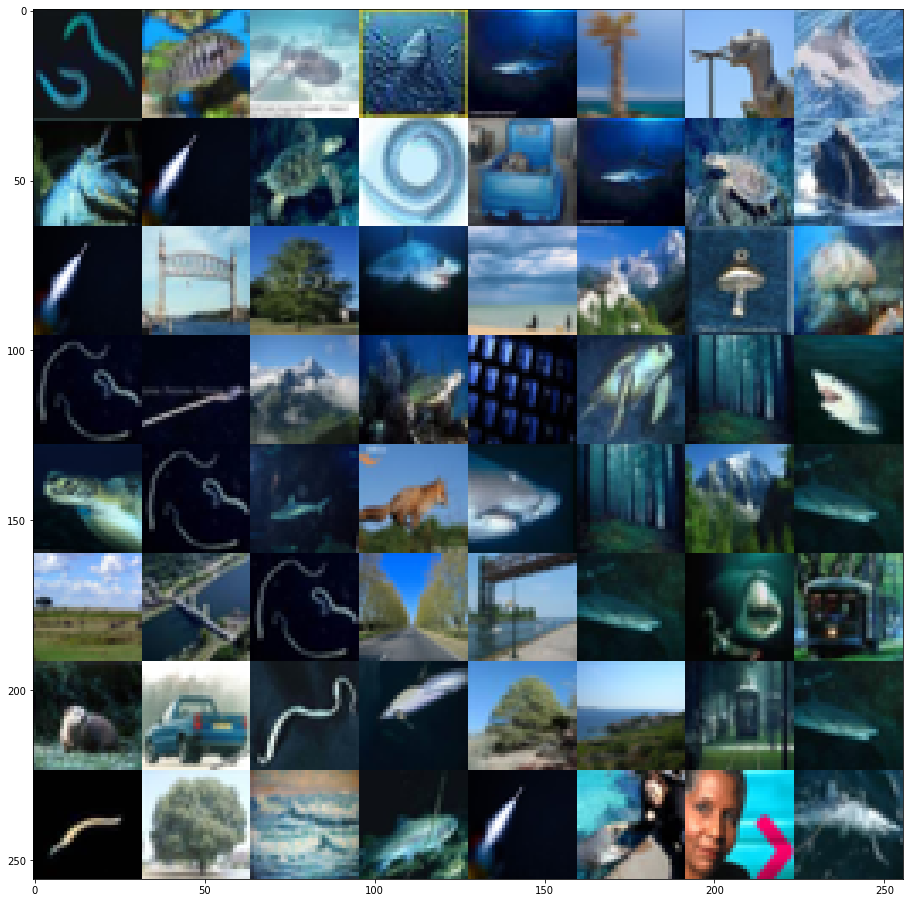

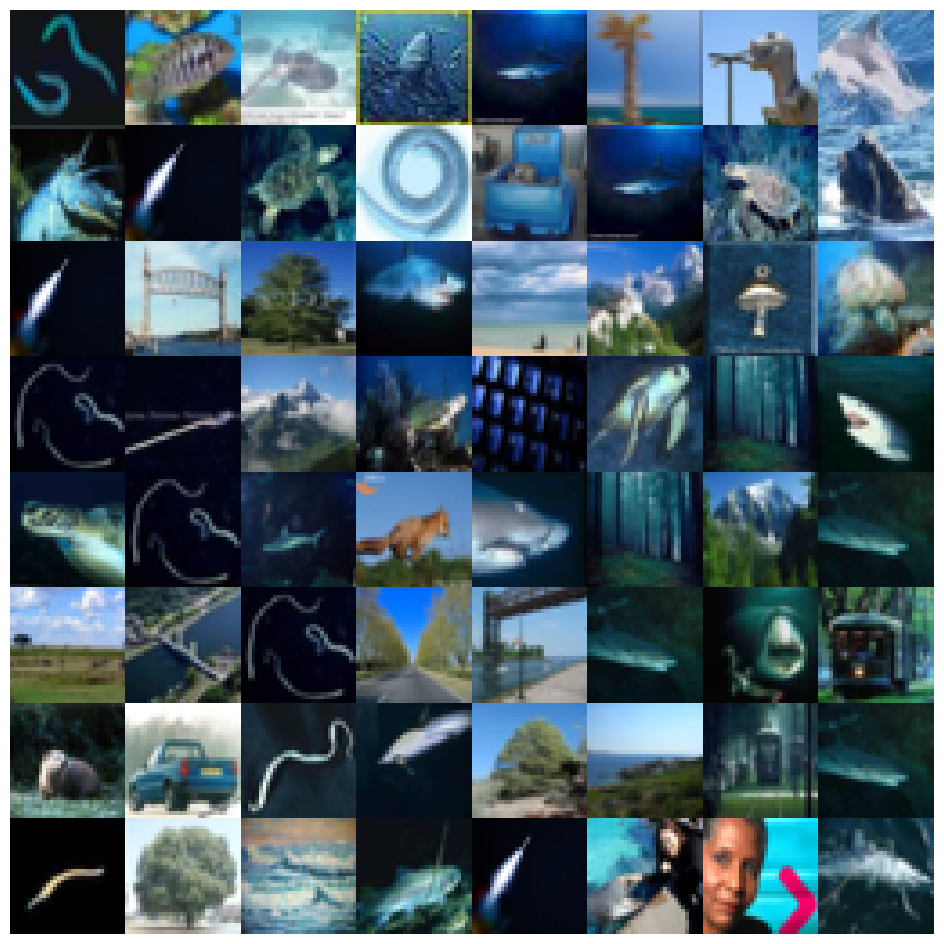

In [ ]:
# your code
#%%pycodestyle

# make output image bigger, output 8x8 tiles, multiply by 32 for correct size
plt.figure(figsize=(12, 12))
plt.imshow(mosaic[:8 * 32, :8 * 32])

# assert image size is correct
img = plt.gca().get_images()[0]
assert img.get_size() == (8 * 32, 8 * 32)

plt.axis('off')
plt.show()

# Bonus [some extra credit, could be a lot if you do something interesting]:
Try to improve this method. If you managed to do someting interesting -- show how the versions compare. Maybe plot the same portions of the mosaic side by side?

- One shortcoming is that we will often get patches of similar images -- can we do something about this in an elegant way? Can you implement this version and compare the results?

- Maybe just taking the mean color is not what we really want? I mean the idea is that the derived color kind of corresponds to how we percieve a tile from afar. Can you propose and test and alternative approach?

- Maybe taking the means loses too much information. Can you try a more fine-grained fingerprint?

- Maybe using the Euclidean distance is not the best way to compare colors? Can you try out some variation?

> An extreme version of this problem is an 'infinite zoom' version done in real-time. So as you keep zooming in the pixels of the tiles would be revealed to be images -- and you could zoom in like that forever. I've never impleented this, but I suspect it's actually feasibly on moderns GPU (similar data-structures are used for raytracing). Maybe some of you have  thoughts on this.

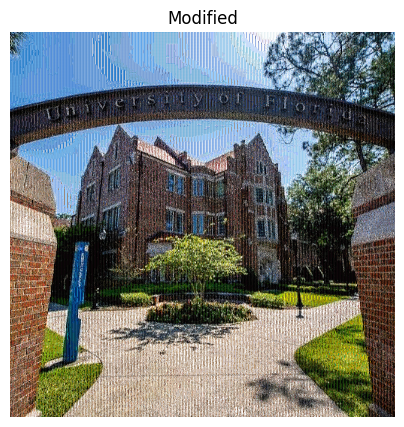

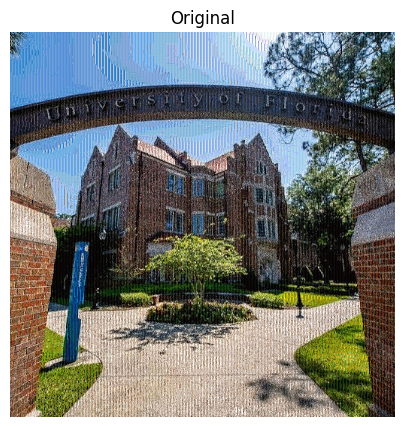

In [ ]:
# attempt to remove using tiles that have been used once until all used once
#%%pycodestyle

# empty set for used images
used_tiles = set()

# create another empty mosaic
mosaic_2 = np.empty((mos.shape[0] * 32, mos.shape[1] * 32, 3), dtype=np.uint8)

for index, (i, j) in enumerate(np.ndindex(mos.shape[:2])):

    # nearest tiles
    nearest_tiles = indice_res[index]

    # tiles not used
    for tile_index in nearest_tiles:
        if tile_index not in used_tiles:
            break

    # delete set of all used tiles
    if len(used_tiles) == len(tiles):
        used_tiles.clear()

    # add tile to set
    used_tiles.add(tile_index)

    # corresponding tile
    tile = tiles[tile_index]

    mosaic_2[i * 32: (i + 1) * 32, j * 32: (j + 1) * 32] = tile

# plot modified and original
plt.figure(figsize=(5, 5))
plt.title('Modified')
plt.imshow(mosaic_2)
plt.axis('off')

plt.figure(figsize=(5, 5))
plt.title('Original')
plt.imshow(mosaic)
plt.axis('off')

plt.show()